# BToM Trajectory Legibility — Cross-Agent Comparison

This notebook adds a **Bayesian Theory of Mind (BToM) goal-inference**
measure of trajectory **legibility** to our 2P3G new-goal analysis, and
compares four populations on it:

* **commit-commit** — `CommittedAgent` vs `CommittedAgent` simulation
  (β = 3.0, λ = 0.125)
* **signal-signal** — `SignalAgent` Bernoulli-mixture variant vs itself
  (β = 3.0, λ = 0.125, p* = 0.375 — the best-fit value from
  `signal_agent_mixture_p_fit_beta3/`)
* **joint-RL**     — joint-RL planner vs itself (softmax β = 3)
* **human-human**  — real human-human dyads from
  `equal_to_both_agent_human_comparison/human_human_pure_unique_2p3g_raw_trials.json`

The measure is adapted from cells 27–32 of
`collabAIdata/analysis_adults_unified_claude.ipynb` (BToM block).

## Method

For each new-goal trial we look at the **sub-trajectory of one player from
`newGoalPresentedTime` until that player stops moving**. We solve a
goal-conditioned MDP by value iteration for two candidate goals:

* **Goal A** = the original shared goal (`firstDetectedSharedGoal`)
* **Goal B** = the new goal (`newGoalPosition`)

Each goal-conditioned policy is turned into a **softmax action distribution**
with inverse temperature β = 2.5. Treating these policies as the likelihood
in Bayes' rule, we update the posterior over (A, B) one observed action at
a time:

$$P_t(g \mid s_{0:t}, a_{0:t-1}) \;\propto\; P_{t-1}(g) \cdot \pi_g(a_{t-1} \mid s_{t-1})$$

Starting from a uniform prior P₀ = (½, ½), this gives a length-(T+1)
posterior trajectory per player-trial. The reported legibility quantity
is the posterior of the **goal that was actually reached**:

$$\text{Legibility}_t = P_t(g^* \mid s_{0:t}, a_{0:t-1}), \qquad g^* \in \{A, B\}.$$

A faster posterior-rise toward 1 means the agent's intent is **more
legible** to an outside observer who knows only the candidate goals.

We run the same analysis twice:
1. **All new-goal trials** — pools `closer_to_player1`,
   `equal_to_both`, and `closer_to_player2` distance conditions.
2. **Equal-to-both only** — restricts to the condition where geometry
   does **not** decide the goal, so legibility is driven by policy.

## Setup

In [ ]:
import functools as ft
import itertools as it
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.interpolate import interp1d

sns.set_theme(style='whitegrid', context='talk')

ROOT = Path('..').resolve()                                # dataAnalysis/
OUT_DIR = ROOT / 'btom_legibility'
OUT_DIR.mkdir(exist_ok=True)

DATA_PATHS = {
    'commit-commit': ROOT / 'committed_vs_committed_simulation'
                          / 'committed_vs_committed_2p3g_raw_trials_sessions_0_to_14.json',
    'signal-signal': ROOT / 'signal_agent_mixture_p_fit_beta3' / 'simulations'
                          / 'signal_vs_signal_2p3g_raw_trials_beta_3_lambda_0p125_alpha_0p375_sessions_0_to_29.json',
    'joint-RL':     ROOT / 'joint_rl_vs_joint_rl_simulation'
                          / 'joint_rl_vs_joint_rl_2p3g_raw_trials_sessions_0_to_29.json',
    'human-human':  ROOT / 'equal_to_both_agent_human_comparison'
                          / 'human_human_pure_unique_2p3g_raw_trials.json',
}

GROUP_ORDER  = ['commit-commit', 'signal-signal', 'joint-RL', 'human-human']
GROUP_PALETTE = {'commit-commit': '#1f77b4', 'signal-signal': '#2ca02c',
                 'joint-RL':      '#7f7f7f', 'human-human':   '#d62728'}

## Goal-conditioned MDP, value iteration, and Bayesian posterior

Same logic as `analysis_adults_unified_claude.ipynb` cell 28.

In [ ]:
ACTION_SPACE = [(0, -1), (0, 1), (-1, 0), (1, 0)]
NOISE_SPACE  = [(0, -1), (0, 1), (-1, 0), (1, 0),
                (1, 1), (1, -1), (-1, -1), (-1, 1)]


class _GridWorld:
    def __init__(self, nx, ny, obstacles=()):
        self.nx, self.ny = nx, ny
        self.obstacles = set(map(tuple, obstacles))

    def is_valid(self, state):
        x, y = state
        return (0 <= x < self.nx and 0 <= y < self.ny
                and state not in self.obstacles)


def _stochastic_transition(state, action, *, terminals, is_valid, noise):
    if state in terminals:
        return {state: 1.0}
    ns = (state[0] + action[0], state[1] + action[1])
    if not is_valid(ns):
        return {state: 1.0}
    candidates = [s for s in ((state[0] + a[0], state[1] + a[1])
                              for a in NOISE_SPACE) if is_valid(s)]
    if len(candidates) <= 1:
        return {ns: 1.0}
    p_noise = noise / (len(candidates) - 1)
    probs = {s: p_noise for s in candidates}
    probs[ns] = 1.0 - noise
    return probs


def _value_iteration(S, A, T, R, gamma, terminals, eps=1e-3, max_iter=200):
    S_nonterm = [s for s in S if s not in terminals]
    V = {s: 0.1 for s in S}
    for s in terminals:
        V[s] = 0.0
    for _ in range(max_iter):
        delta = 0.0
        for s in S_nonterm:
            old = V[s]
            V[s] = max(
                sum(p * (R[s][a][sn] + gamma * V[sn])
                    for sn, p in T[s][a].items())
                for a in A
            )
            delta = max(delta, abs(V[s] - old))
        if delta < eps:
            break
    return V


def solve_goal_policy(goal, grid_size=15, noise=0.067, gamma=0.9,
                      goal_reward=30, obstacles=()):
    env = _GridWorld(grid_size, grid_size, obstacles)
    goal = tuple(int(v) for v in goal)
    terminals = {goal}
    S = [s for s in it.product(range(grid_size), range(grid_size))
         if s not in env.obstacles]
    A = ACTION_SPACE
    tf = ft.partial(_stochastic_transition,
                    terminals=terminals, is_valid=env.is_valid, noise=noise)
    T = {s: {a: tf(s, a) for a in A} for s in S}
    step_cost = -1.0 / (grid_size * 2)
    R = {}
    for s in S:
        R[s] = {}
        for a in A:
            R[s][a] = {}
            for sn in T[s][a]:
                R[s][a][sn] = step_cost + (goal_reward if sn in terminals else 0.0)
    V = _value_iteration(S, A, T, R, gamma, terminals)
    for s in terminals:
        V[s] = goal_reward
    Q = {}
    for s in S:
        Q[s] = {}
        for a in A:
            Q[s][a] = sum(p * (R[s][a][sn] + gamma * V[sn])
                          for sn, p in T[s][a].items())
    return Q


def softmax_action_probs(Q_state, beta=2.5):
    if not Q_state:
        return {}
    actions = list(Q_state.keys())
    vals = np.array([Q_state[a] for a in actions])
    vals = vals - vals.max()
    e = np.exp(beta * vals)
    return dict(zip(actions, e / e.sum()))


def infer_goal_posteriors(traj_states, actions, Q_A, Q_B, beta=2.5):
    prior = [0.5, 0.5]
    posts = [list(prior)]
    for pos, act in zip(traj_states, actions):
        pos = tuple(int(v) for v in pos)
        act = tuple(int(v) for v in act)
        pA = softmax_action_probs(Q_A.get(pos, {}), beta)
        pB = softmax_action_probs(Q_B.get(pos, {}), beta)
        lA = pA.get(act, 1e-10)
        lB = pB.get(act, 1e-10)
        un = [prior[0] * lA, prior[1] * lB]
        Z = sum(un)
        prior = [u / Z for u in un] if Z > 0 else [0.5, 0.5]
        posts.append(list(prior))
    return posts

## Per-trial BToM and per-group loading

For each new-goal trial we compute the posterior trajectory for **both
players**. An optional `condition_filter` lets us restrict to a single
distance condition (used below for the equal-to-both panel).

In [ ]:
_q_cache = {}

def get_Q(goal):
    g = tuple(int(v) for v in goal)
    if g not in _q_cache:
        _q_cache[g] = solve_goal_policy(g)
    return _q_cache[g]


def _actions_from_traj(traj):
    return [(int(traj[i + 1][0]) - int(traj[i][0]),
             int(traj[i + 1][1]) - int(traj[i][1])) for i in range(len(traj) - 1)]


def btom_for_player(row, player_index):
    target1, target2 = row.get('target1'), row.get('target2')
    new_goal_pos     = row.get('newGoalPosition')
    if target1 is None or target2 is None or new_goal_pos is None:
        return None
    try:
        shared_idx = int(row.get('firstDetectedSharedGoal'))
    except (TypeError, ValueError):
        return None
    if shared_idx not in (0, 1):
        return None
    goalA = target1 if shared_idx == 0 else target2
    goalB = new_goal_pos
    final_col = f'player{player_index + 1}FinalReachedGoal'
    try:
        final_idx = int(row.get(final_col))
    except (TypeError, ValueError):
        return None
    if final_idx == shared_idx:
        reached_idx = 0
    elif final_idx == 2:
        reached_idx = 1
    else:
        return None
    traj_col = f'player{player_index + 1}Trajectory'
    traj = row.get(traj_col)
    if not traj or len(traj) < 2:
        return None
    try:
        ngt = int(row.get('newGoalPresentedTime'))
    except (TypeError, ValueError):
        return None
    if ngt < 0 or ngt >= len(traj) - 1:
        return None
    sub_traj = traj[ngt:]
    sub_acts = _actions_from_traj(sub_traj)
    if len(sub_acts) < 1:
        return None
    Q_A = get_Q(tuple(goalA))
    Q_B = get_Q(tuple(goalB))
    posts = infer_goal_posteriors(sub_traj[:-1], sub_acts, Q_A, Q_B, beta=2.5)
    return [p[reached_idx] for p in posts]


def load_group(name, fp, condition_filter=None):
    trials = json.load(open(fp))
    rows = []
    for t in trials:
        if not t.get('newGoalPresented'):
            continue
        if condition_filter is not None and t.get('distanceCondition') != condition_filter:
            continue
        for player_index in (0, 1):
            posts = btom_for_player(t, player_index)
            if posts is None:
                continue
            pid_field = f'participantId_player{player_index + 1}'
            if pid_field in t:
                pid = t[pid_field]
            elif 'participantId' in t and player_index == 0:
                pid = t['participantId']
            else:
                pid = f"{name}_session_{t.get('sessionIndex','?')}_p{player_index + 1}"
            rows.append({
                'group':         name,
                'participantId': str(pid),
                'trialIndex':    t.get('trialIndex'),
                'playerIndex':   player_index,
                'distanceCondition': t.get('distanceCondition'),
                'posteriors':    posts,
                'n_steps':       len(posts),
            })
    return pd.DataFrame(rows)


def build_dataset(condition_filter):
    frames = []
    for name in GROUP_ORDER:
        fp = DATA_PATHS[name]
        if not fp.exists():
            print(f'  [skip] {name}: missing {fp}')
            continue
        df = load_group(name, fp, condition_filter)
        print(f'  {name}: {len(df)} player-trials  '
              f'(unique pid={df["participantId"].nunique()})')
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


print('Building all-new-goal dataset ...')
df_all = build_dataset(None)
print(f'  total = {len(df_all)}')
print('\nBuilding equal_to_both dataset ...')
df_equal = build_dataset('equal_to_both')
print(f'  total = {len(df_equal)}')
print(f'\nQ-cache size: {len(_q_cache)} unique goals')

Building all-new-goal dataset ...
  commit-commit: 268 player-trials  (unique pid=30)
  signal-signal: 476 player-trials  (unique pid=60)
  joint-RL: 482 player-trials  (unique pid=60)
  human-human: 264 player-trials  (unique pid=32)
  total = 1490

Building equal_to_both dataset ...
  commit-commit: 90 player-trials  (unique pid=30)
  signal-signal: 130 player-trials  (unique pid=58)
  joint-RL: 145 player-trials  (unique pid=60)
  human-human: 94 player-trials  (unique pid=32)
  total = 459

Q-cache size: 189 unique goals


## Aggregation helpers

For each dataset we derive four panels:
* `btom_part`      — per-participant posterior at 11 evenly spaced
  trajectory-progress points (0%, 10%, …, 100%)
* `btom_step_part` — per-participant posterior at the first
  6 absolute step indices (0, 1, …, 5)
* `btom_step_mean` — per-participant **mean** posterior across the
  first 5 steps
* `btom_traj_mean` — per-participant **mean** posterior across the full
  sub-trajectory

In [ ]:
def derive_panels(btom_df):
    N_INTERP = 11
    x_pct = np.linspace(0, 1, N_INTERP)

    def interp(pl):
        if len(pl) < 2:
            return None
        return interp1d(np.linspace(0, 1, len(pl)), pl, kind='linear')(x_pct)

    df = btom_df.copy()
    df['btom_interp'] = df['posteriors'].apply(interp)
    df = df.dropna(subset=['btom_interp']).copy()

    rows = []
    for _, r in df.iterrows():
        for ti, val in enumerate(r['btom_interp']):
            rows.append({'group': r['group'], 'participantId': r['participantId'],
                         'time_pct': x_pct[ti] * 100, 'posterior': val})
    btom_long = pd.DataFrame(rows)
    btom_part = (btom_long
                 .groupby(['participantId', 'group', 'time_pct'], observed=False)['posterior']
                 .mean().reset_index())

    MAX_STEP = 5
    rows = []
    for _, r in btom_df.iterrows():
        for step, val in enumerate(r['posteriors'][:MAX_STEP + 1]):
            rows.append({'group': r['group'], 'participantId': r['participantId'],
                         'step': step, 'posterior': val})
    btom_step_long = pd.DataFrame(rows)
    btom_step_part = (btom_step_long
                      .groupby(['participantId', 'group', 'step'], observed=False)['posterior']
                      .mean().reset_index())

    btom_step_mean = (btom_step_part
                      .groupby(['participantId', 'group'], observed=False)['posterior']
                      .mean().reset_index())
    btom_traj_mean = (btom_part
                      .groupby(['participantId', 'group'], observed=False)['posterior']
                      .mean().reset_index())
    return btom_part, btom_step_part, btom_step_mean, btom_traj_mean


panels_all   = derive_panels(df_all)
panels_equal = derive_panels(df_equal)
TITLES = ('All new-goal trials', 'Equal-to-both only')

## Plot 1: Posterior over % trajectory — side-by-side

Posteriors interpolated to 11 evenly spaced points and averaged within
participant. Left panel pools all new-goal trials; right panel restricts
to `equal_to_both`.

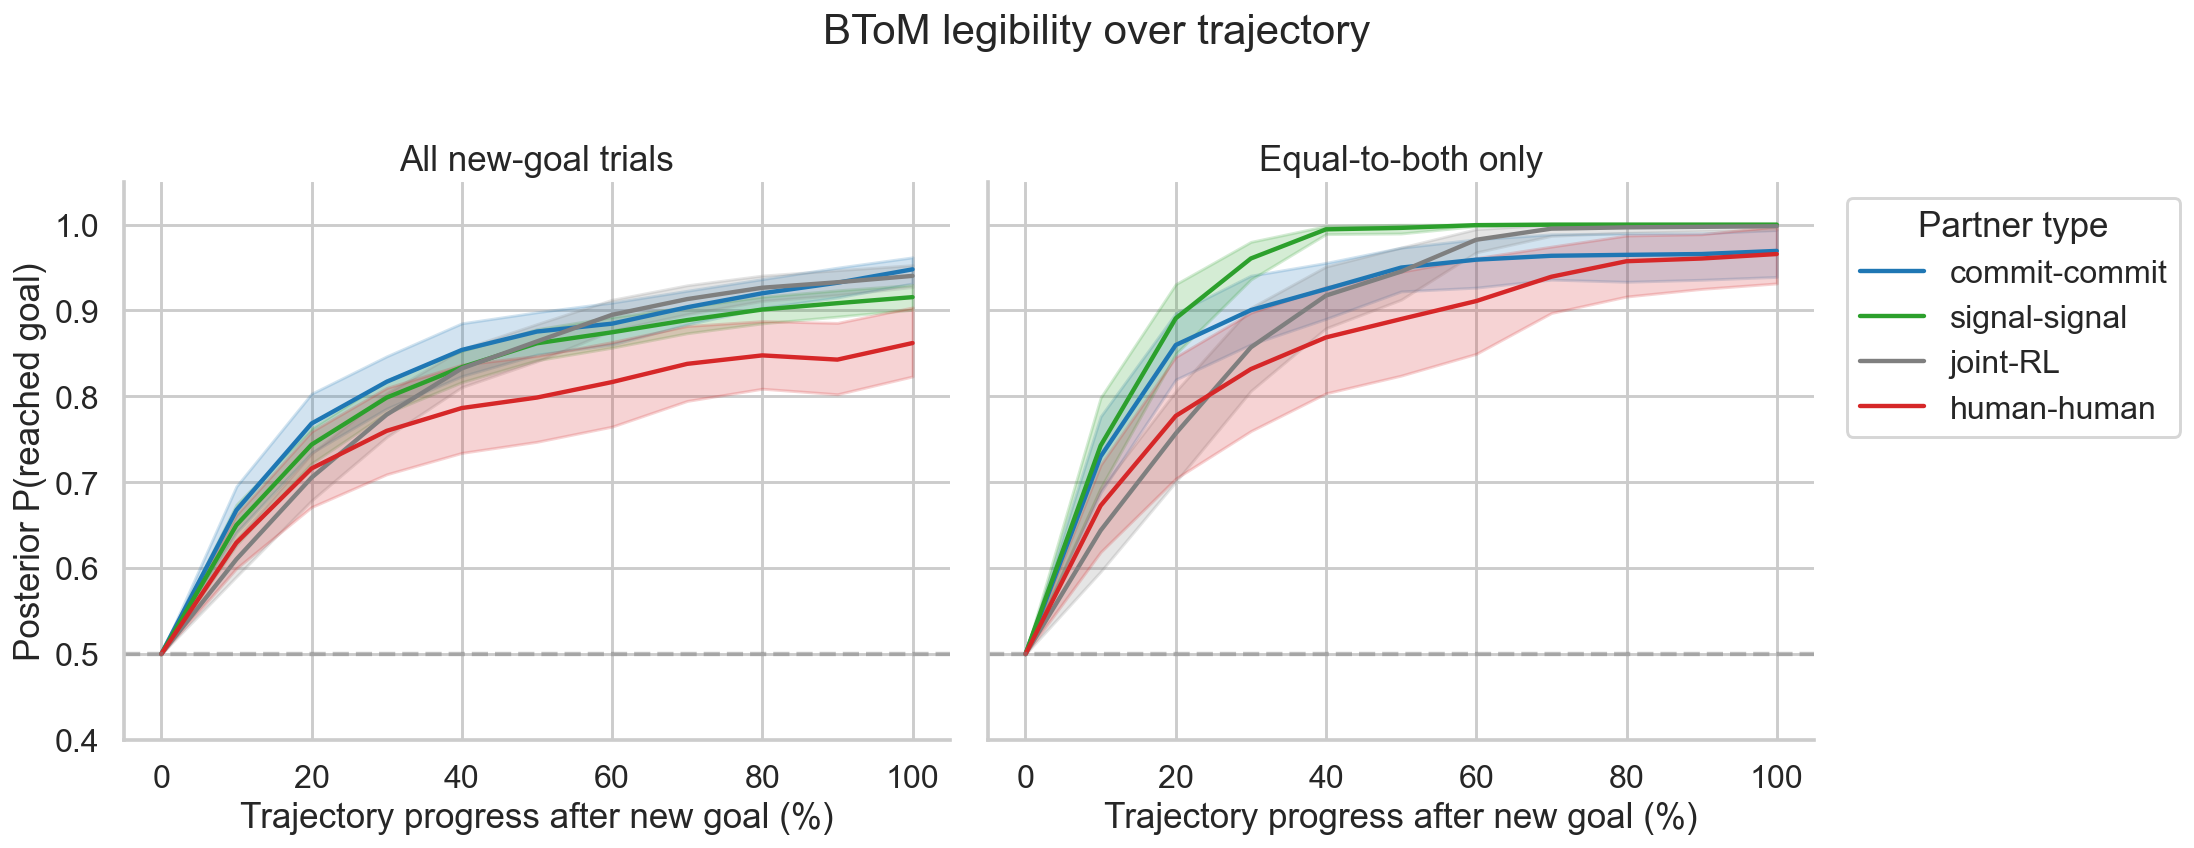

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, panels, title in zip(axes, (panels_all, panels_equal), TITLES):
    btom_part = panels[0]
    sns.lineplot(data=btom_part, x='time_pct', y='posterior',
                 hue='group', hue_order=GROUP_ORDER, palette=GROUP_PALETTE,
                 errorbar=('ci', 95), ax=ax, legend=(ax is axes[1]))
    ax.axhline(0.5, ls='--', color='grey', alpha=0.5)
    ax.set(xlabel='Trajectory progress after new goal (%)',
           ylabel='Posterior P(reached goal)' if ax is axes[0] else '',
           title=title, ylim=(0.4, 1.05))
axes[1].legend(title='Partner type', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle('BToM legibility over trajectory', y=1.02)
sns.despine(); plt.tight_layout(); plt.show()

## Plot 2: Posterior over first 5 steps — side-by-side

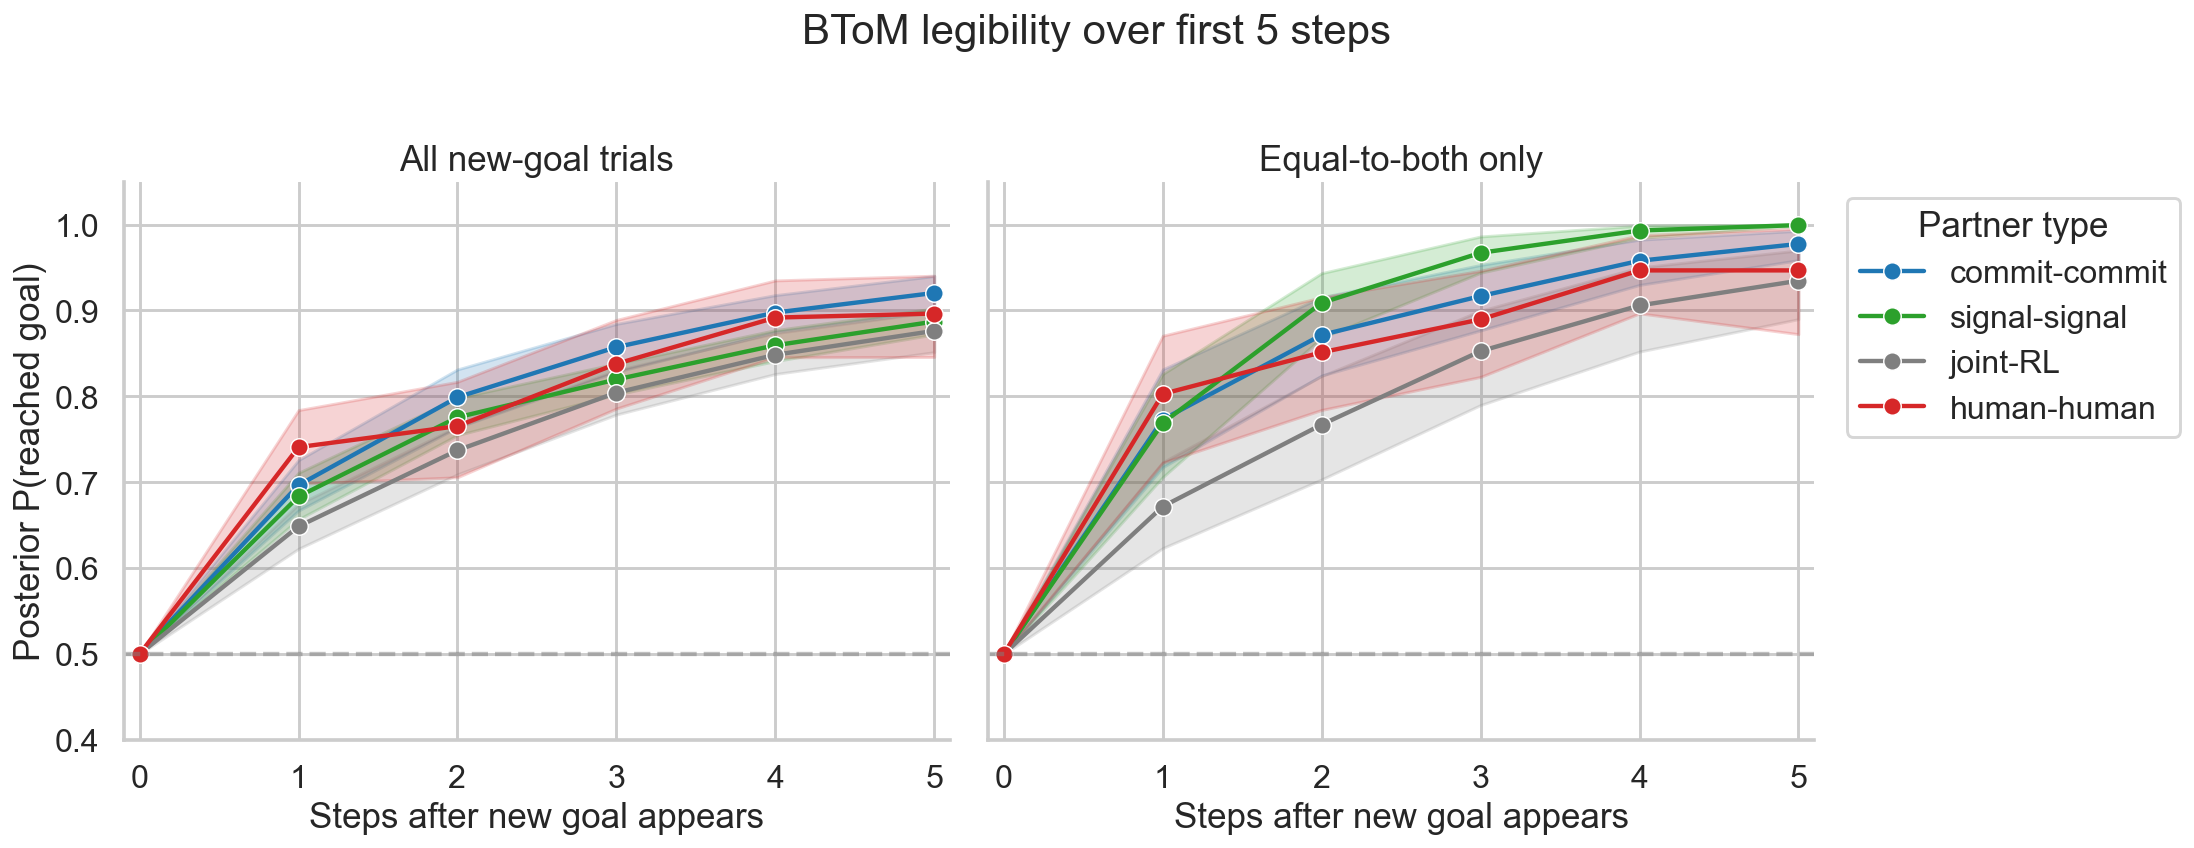

In [ ]:
MAX_STEP = 5
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, panels, title in zip(axes, (panels_all, panels_equal), TITLES):
    btom_step_part = panels[1]
    sns.lineplot(data=btom_step_part, x='step', y='posterior',
                 hue='group', hue_order=GROUP_ORDER, palette=GROUP_PALETTE,
                 errorbar=('ci', 95), marker='o', ax=ax,
                 legend=(ax is axes[1]))
    ax.axhline(0.5, ls='--', color='grey', alpha=0.5)
    ax.set(xlabel='Steps after new goal appears',
           ylabel='Posterior P(reached goal)' if ax is axes[0] else '',
           title=title, xlim=(-0.1, MAX_STEP + 0.1), ylim=(0.4, 1.05))
    ax.set_xticks(range(MAX_STEP + 1))
axes[1].legend(title='Partner type', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle('BToM legibility over first 5 steps', y=1.02)
sns.despine(); plt.tight_layout(); plt.show()

## Plot 3: Mean posterior across first 5 steps — side-by-side

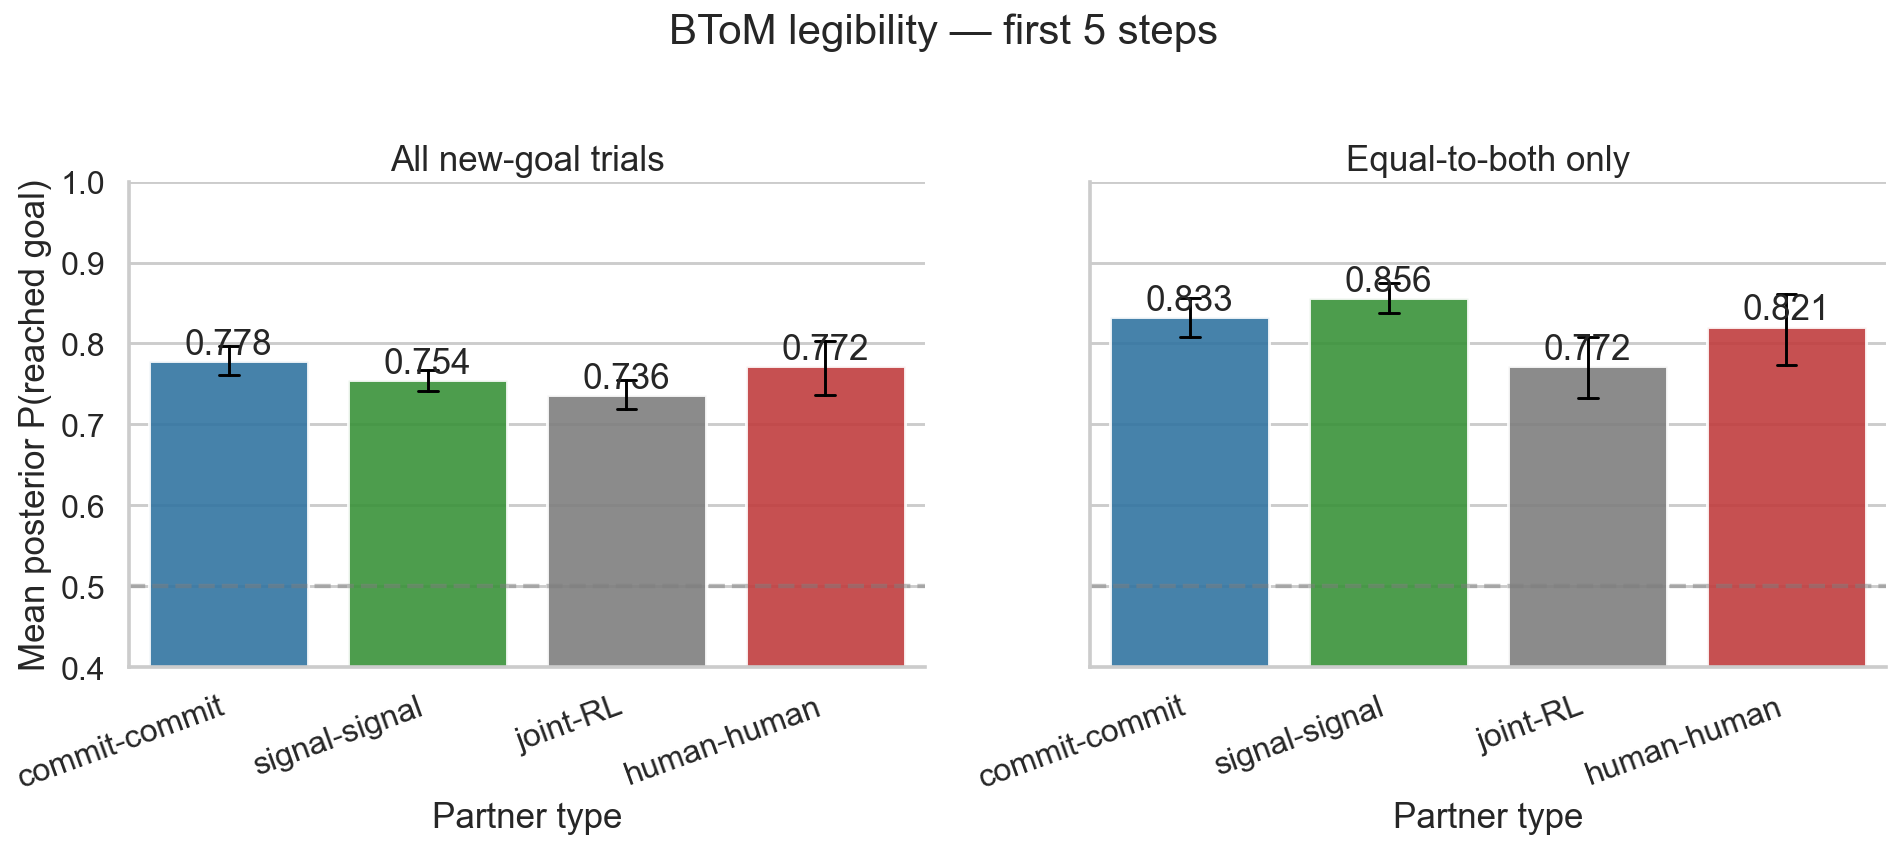

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, panels, title in zip(axes, (panels_all, panels_equal), TITLES):
    btom_step_mean = panels[2]
    sns.barplot(data=btom_step_mean, x='group', y='posterior',
                order=GROUP_ORDER, hue='group', palette=GROUP_PALETTE,
                legend=False, errorbar=('ci', 95),
                err_kws={'color': 'black', 'linewidth': 1.5}, capsize=0.1,
                alpha=0.9, ax=ax)
    ax.axhline(0.5, ls='--', color='grey', alpha=0.5)
    ax.set(xlabel='Partner type',
           ylabel='Mean posterior P(reached goal)' if ax is axes[0] else '',
           title=title, ylim=(0.4, 1.0))
    for c in ax.containers:
        ax.bar_label(c, fmt='%.3f')
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(20); lbl.set_ha('right')
fig.suptitle('BToM legibility — first 5 steps', y=1.02)
sns.despine(); plt.tight_layout(); plt.show()

## Plot 4: Mean posterior over full sub-trajectory — side-by-side

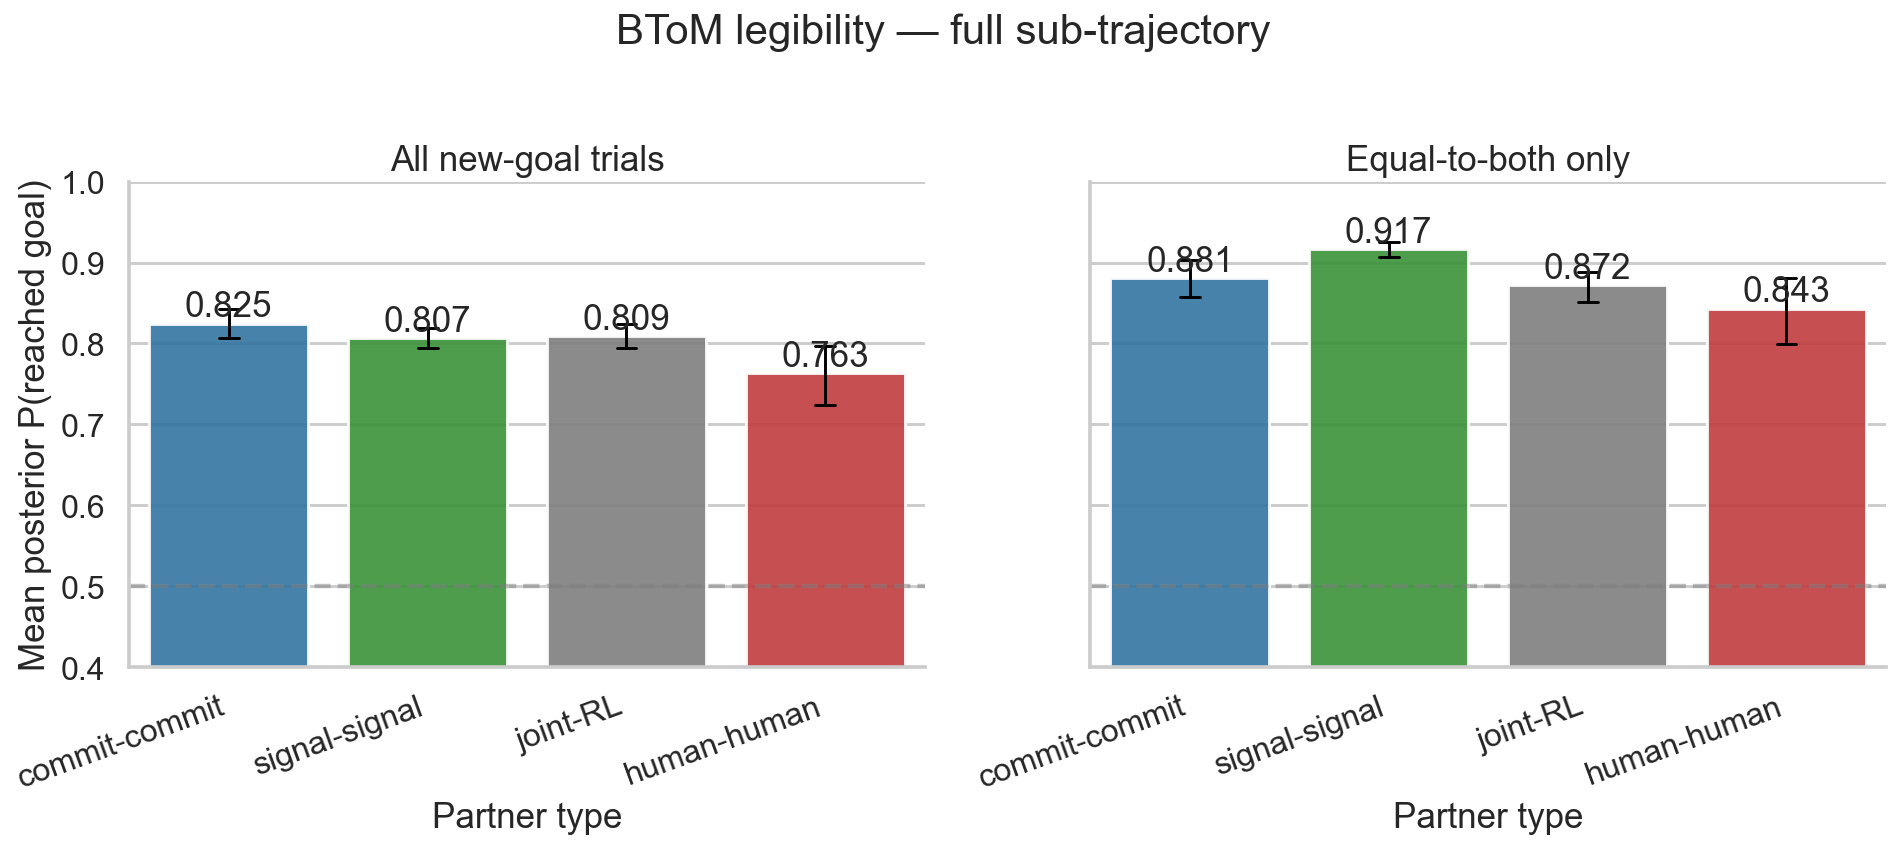

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, panels, title in zip(axes, (panels_all, panels_equal), TITLES):
    btom_traj_mean = panels[3]
    sns.barplot(data=btom_traj_mean, x='group', y='posterior',
                order=GROUP_ORDER, hue='group', palette=GROUP_PALETTE,
                legend=False, errorbar=('ci', 95),
                err_kws={'color': 'black', 'linewidth': 1.5}, capsize=0.1,
                alpha=0.9, ax=ax)
    ax.axhline(0.5, ls='--', color='grey', alpha=0.5)
    ax.set(xlabel='Partner type',
           ylabel='Mean posterior P(reached goal)' if ax is axes[0] else '',
           title=title, ylim=(0.4, 1.0))
    for c in ax.containers:
        ax.bar_label(c, fmt='%.3f')
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(20); lbl.set_ha('right')
fig.suptitle('BToM legibility — full sub-trajectory', y=1.02)
sns.despine(); plt.tight_layout(); plt.show()

## Summary tables

In [ ]:
sumtab = []
for cond_label, panels in [('all_new_goal', panels_all),
                           ('equal_to_both', panels_equal)]:
    _, _, step_mean, traj_mean = panels
    s5 = (step_mean.groupby('group', observed=False)['posterior']
          .agg(['mean', 'std', 'count']).reset_index())
    s5.insert(0, 'condition', cond_label); s5.insert(2, 'measure', 'first5')
    sf = (traj_mean.groupby('group', observed=False)['posterior']
          .agg(['mean', 'std', 'count']).reset_index())
    sf.insert(0, 'condition', cond_label); sf.insert(2, 'measure', 'full_traj')
    sumtab.append(s5); sumtab.append(sf)
summary = pd.concat(sumtab, ignore_index=True)
print(summary.to_string(index=False))

    condition         group   measure     mean      std  count
 all_new_goal commit-commit    first5 0.778489 0.051307     30
 all_new_goal   human-human    first5 0.772049 0.098346     32
 all_new_goal      joint-RL    first5 0.735816 0.072956     60
 all_new_goal signal-signal    first5 0.754226 0.051957     60
 all_new_goal commit-commit full_traj 0.824652 0.050807     30
 all_new_goal   human-human full_traj 0.763432 0.105400     32
 all_new_goal      joint-RL full_traj 0.808993 0.060692     60
 all_new_goal signal-signal full_traj 0.807001 0.050131     60
equal_to_both commit-commit    first5 0.832807 0.071115     30
equal_to_both   human-human    first5 0.820810 0.125306     32
equal_to_both      joint-RL    first5 0.772018 0.143548     60
equal_to_both signal-signal    first5 0.856281 0.069156     58
equal_to_both commit-commit full_traj 0.880736 0.063974     30
equal_to_both   human-human full_traj 0.843137 0.111834     32
equal_to_both      joint-RL full_traj 0.871869 0.073979

## Notes & interpretation

* All four populations clear chance (0.5) within the first step and
  rise toward 1 — the goal-conditioned softmax policies make goals
  identifiable from short action prefixes in this 15×15 grid.
* **All new-goal trials** (left panels) give the easier baseline: many
  trials are `closer_to_player1` / `closer_to_player2`, where geometry
  alone reveals the goal. Mean first-5-step posteriors cluster within
  ~0.04 of each other; commit-commit (0.778) and human-human (0.772)
  edge out signal-signal (0.754) and joint-RL (0.736).
* **Equal-to-both only** (right panels) is the policy-driven test.
  Mean posteriors rise across the board, and the **ranking changes**:
  signal-signal becomes the most legible
  (first-5: 0.856; full-traj: 0.917), with commit-commit second
  (0.833 / 0.881) and joint-RL last among the agents (0.772 / 0.872).
  This is exactly what the Bernoulli-mixture model predicts: when
  geometry is uninformative, the progress-maximising signal moves
  inserted with prob p* = 0.375 produce more single-goal-directed
  trajectories than commit alone.
* **Humans** sit between commit-commit and joint-RL on the first-5-step
  measure in equal-to-both (0.821) and have the **lowest** full-trajectory
  legibility (0.843). They signal early, then their later steps include
  detours and coordination delays that drag the posterior down — a
  pattern none of the three agent classes reproduces exactly.

## Files

* Notebook — `btom_legibility/BToM_legibility_comparison.ipynb`
* Scripts  — `scripts/btom_compare_agents.py`,
             `scripts/btom_compare_agents_sidebyside.py`
* CSVs     — `btom_legibility/btom_*.csv`
* PNGs     — `btom_legibility/btom_*_sidebyside.png` (paired figures
             used above) and `btom_legibility/btom_*.png` (single-panel
             versions of each plot for the all-new-goal data)